In [1]:
# standard python imports
import numpy as np
import matplotlib.pylab as plt

# tidy3D import
import tidy3d as td
from tidy3d.constants import C_0
from tidy3d.plugins.mode import ModeSolver

import xarray as xr
td.config.logging_level = 'ERROR'

# size of simulation domain
Lx, Ly, Lz = 2, 2, 2
Lx, Ly, Lz = 1,1,1
dl = 0.06667
# dl = 0.05

# waveguide information
wg_width = 0.7
wg_permittivity = 3.47**2
plane_size = (4, 0, 3.5)

# central frequency
wvl_um = 1.55
freq0 = C_0 / wvl_um
fwidth = freq0 / 3

# run_time in ps
run_time = 1e-12

# automatic grid specification
# grid_spec = td.GridSpec.auto(min_steps_per_wvl=20, wavelength=wvl_um)
grid_spec = td.GridSpec.uniform(dl=dl)

plane = td.Box(center=(0, 0, 0), size=plane_size)
mode_spec = td.ModeSpec(
    num_modes=3,
)
freqs = [freq0]

def solve_one_width(wg_width, run_remote=False, custom=False):
    mesh = td.TriangleMesh.from_stl("./wg.stl", scale=(wg_width / 0.5, 1, 1))

    print("solve with: ", mesh.bounding_box)

    waveguide = td.Structure(
        geometry=mesh,
        medium=td.Medium(permittivity=wg_permittivity),
    
    )

    if custom:
        import custom.spatial_medium as sm
        sim = td.Simulation(
        size=(Lx, Ly, Lz),
        grid_spec=grid_spec,
        structures=[waveguide],
        run_time=run_time,
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.Periodic()),
        medium=td.Medium(permittivity=1.444**2),
        )
        sm.SpatialMediumCreator5.MAX_ITERATIONS = 5
        creator = sm.SpatialMediumCreator5(sim)
        medium, _ = creator.create()

        waveguide = td.Structure(
            geometry=mesh,
            medium = medium,
        )

    sim = td.Simulation(
        size=(Lx, Ly, Lz),
        grid_spec=grid_spec,
        structures=[waveguide],
        run_time=run_time,
        boundary_spec=td.BoundarySpec.all_sides(boundary=td.Periodic()),
        medium=td.Medium(permittivity=1.444**2),
        subpixel = run_remote
    )

    mode_solver = ModeSolver(
        simulation=sim,
        plane=plane,
        mode_spec=mode_spec,
        freqs=freqs,
    )
    if run_remote:
        from tidy3d.plugins.mode.web import run as run_mode_solver
        mode_data = run_mode_solver(mode_solver)
    else:
        mode_data = mode_solver.solve()
    return mode_data

solve by width 未使用subpixel

solve with:  attrs={} type='Box' center=(0.0, 0.0, -1.4901199999611814e-07) size=(0.39999995231679997, 0.40000000596, 0.22000046074399998)
solve with:  attrs={} type='Box' center=(0.0, 0.0, -1.4901199999611814e-07) size=(0.46666661103626667, 0.40000000596, 0.22000046074399998)
solve with:  attrs={} type='Box' center=(0.0, 0.0, -1.4901199999611814e-07) size=(0.5333332697557334, 0.40000000596, 0.22000046074399998)
solve with:  attrs={} type='Box' center=(0.0, 0.0, -1.4901199999611814e-07) size=(0.5999999284752, 0.40000000596, 0.22000046074399998)
solve with:  attrs={} type='Box' center=(0.0, 0.0, -1.4901199999611814e-07) size=(0.6666665871946668, 0.40000000596, 0.22000046074399998)
solve with:  attrs={} type='Box' center=(0.0, 0.0, -1.4901199999611814e-07) size=(0.7333332459141334, 0.40000000596, 0.22000046074399998)
solve with:  attrs={} type='Box' center=(0.0, 0.0, -1.4901199999611814e-07) size=(0.7999999046336, 0.40000000596, 0.22000046074399998)
solve with:  attrs={} type='Box' cente

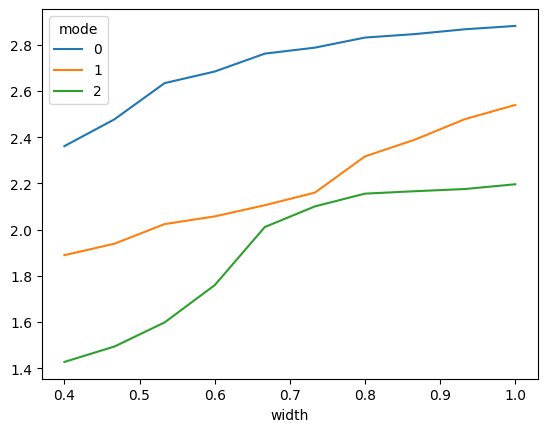

In [2]:
nums_width = 10
width = 0.3
widths = np.linspace(wg_width - width, wg_width + width, nums_width)
neffs = []
for w in widths:
    mode_data = solve_one_width(w)
    neffs.append(mode_data.n_eff.values[0])

da = xr.DataArray(neffs, coords={'width': widths, 'mode': np.arange(3)})
da.plot.line(x='width')


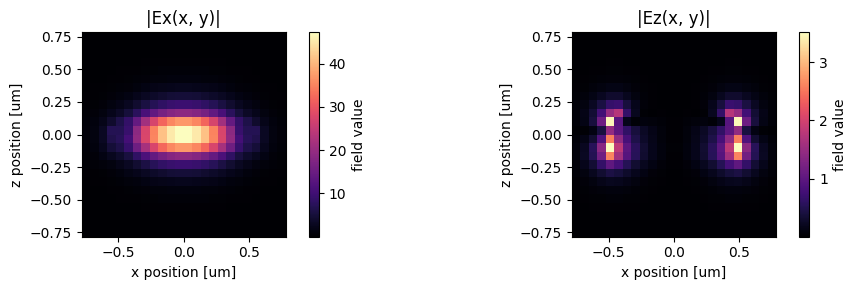

In [3]:
f0_ind = 0
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
abs(mode_data.Ex.isel(mode_index=0, f=f0_ind)).plot(x="x", y="z", ax=ax1, cmap="magma")
abs(mode_data.Ez.isel(mode_index=0, f=f0_ind)).plot(x="x", y="z", ax=ax2, cmap="magma")

ax1.set_title("|Ex(x, y)|")
ax1.set_aspect("equal")
ax2.set_title("|Ez(x, y)|")
ax2.set_aspect("equal")
plt.show()

solve with:  attrs={} type='Box' center=(0.0, 0.0, -1.4901199999611814e-07) size=(0.39999995231679997, 0.40000000596, 0.22000046074399998)
process total cells: 97336 on 20 cores, iterations: 5
Calc Time elapsed: 594.9192677000538
Average Time elapsed: 53.17359750001924
solve with:  attrs={} type='Box' center=(0.0, 0.0, -1.4901199999611814e-07) size=(0.46666661103626667, 0.40000000596, 0.22000046074399998)
process total cells: 97336 on 20 cores, iterations: 5
Calc Time elapsed: 620.8048572000116
Average Time elapsed: 60.19910040003015
solve with:  attrs={} type='Box' center=(0.0, 0.0, -1.4901199999611814e-07) size=(0.5333332697557334, 0.40000000596, 0.22000046074399998)
process total cells: 97336 on 20 cores, iterations: 5
Calc Time elapsed: 675.529409300012
Average Time elapsed: 61.35141780000413
solve with:  attrs={} type='Box' center=(0.0, 0.0, -1.4901199999611814e-07) size=(0.5999999284752, 0.40000000596, 0.22000046074399998)
process total cells: 97336 on 20 cores, iterations: 5
Cal

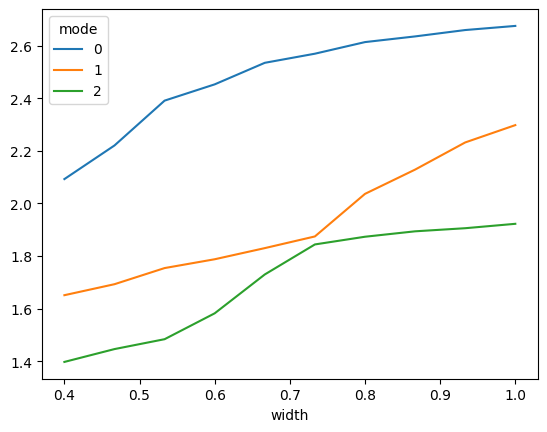

In [4]:
neffs = []
for w in widths:
    mode_data = solve_one_width(w, False, True)
    neffs.append(mode_data.n_eff.values[0])

da3 = xr.DataArray(neffs, coords={'width': widths, 'mode': np.arange(3)})
da3.plot.line(x='width')

solve with:  attrs={} type='Box' center=(0.0, 0.0, -1.4901199999611814e-07) size=(0.39999995231679997, 0.40000000596, 0.22000046074399998)


09:46:12 中国标准时间 Mode solver created with                                  
                      task_id='fdve-e8f52967-a1a4-47b6-a63d-c807cb2d6a71',      
                      solver_id='mo-db0e4f86-a1c2-4268-8d07-3edb871c4c1a'.

Output()

Output()

09:46:18 中国标准时间 Mode solver status: queued

...

Output()

09:49:16 中国标准时间 Mode solver status: queued

09:49:39 中国标准时间 Mode solver status: running

09:49:46 中国标准时间 Mode solver status: success

Output()

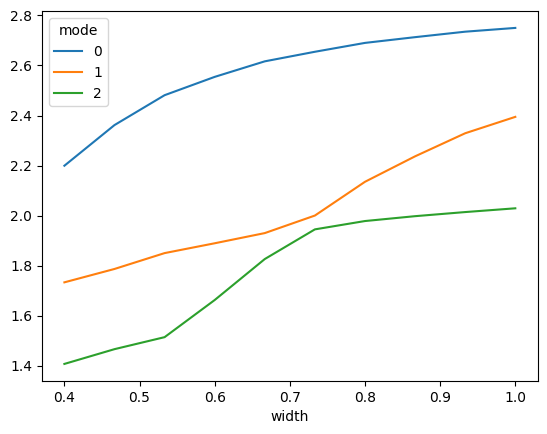

In [5]:
neffs = []
for w in widths:
    mode_data = solve_one_width(w, True)
    neffs.append(mode_data.n_eff.values[0])

da2 = xr.DataArray(neffs, coords={'width': widths, 'mode': np.arange(3)})
da2.plot.line(x='width')

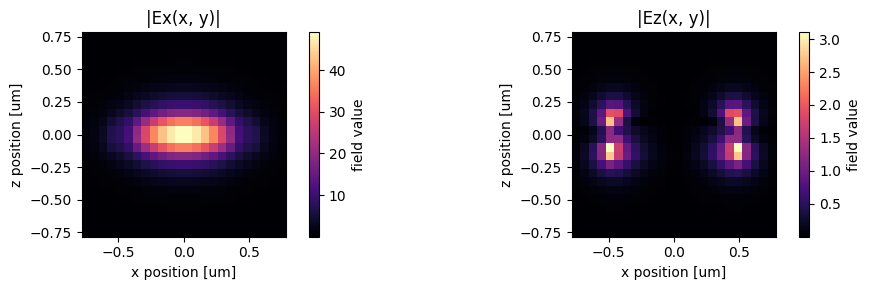

In [6]:
f0_ind = 0
f, (ax1, ax2) = plt.subplots(1, 2, tight_layout=True, figsize=(10, 3))
abs(mode_data.Ex.isel(mode_index=0, f=f0_ind)).plot(x="x", y="z", ax=ax1, cmap="magma")
abs(mode_data.Ez.isel(mode_index=0, f=f0_ind)).plot(x="x", y="z", ax=ax2, cmap="magma")

ax1.set_title("|Ex(x, y)|")
ax1.set_aspect("equal")
ax2.set_title("|Ez(x, y)|")
ax2.set_aspect("equal")
plt.show()

tidy3d未使用subpixel与remote使用对比

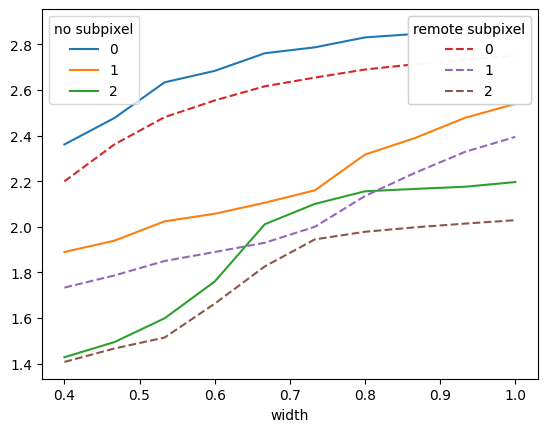

In [7]:
fig, ax = plt.subplots()
l1 = da.plot.line(x='width', ax=ax, add_legend=False)
for i in range(len(l1)):
    l1[i].set_label(i)
legend1 = ax.legend(handles=l1, title='no subpixel', loc='upper left')
ax.add_artist(legend1)
l2 = da2.plot.line(x='width', ax=ax, linestyle='--', add_legend=False)
for i in range(len(l2)):
    l2[i].set_label(i)
legend2 = ax.legend(handles=l2, title='remote subpixel', loc='upper right')
ax.add_artist(legend2)


remote subpixel 与本地subpixel对比

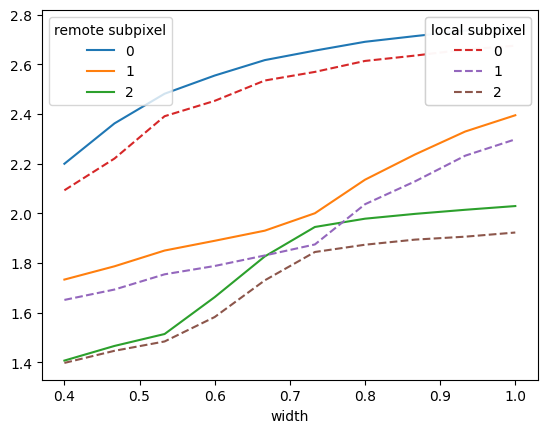

In [8]:
fig, ax = plt.subplots()
l1 = da2.plot.line(x='width', ax=ax, add_legend=False)
for i in range(len(l1)):
    l1[i].set_label(i)
legend1 = ax.legend(handles=l1, title='remote subpixel', loc='upper left')
ax.add_artist(legend1)
l2 = da3.plot.line(x='width', ax=ax, linestyle='--', add_legend=False)
for i in range(len(l2)):
    l2[i].set_label(i)
legend2 = ax.legend(handles=l2, title='local subpixel', loc='upper right')
ax.add_artist(legend2)